In [3]:
import numpy as np
import pandas as pd
df = pd.read_csv(r'Fraud Detection Dataset.csv')

In [4]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [5]:
df.tail()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0
50999,T13665,2315,814.72,POS Payment,3.0,Tablet,Los Angeles,0,50,10,Invalid Method,0


In [7]:
df.shape

(51000, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [9]:
df.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [11]:
df.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [29]:
df['Transaction_Amount'] = df['Transaction_Amount'].fillna(df['Transaction_Amount'].median())
df['Time_of_Transaction'] = df['Time_of_Transaction'].fillna(df['Time_of_Transaction'].median())

In [30]:
df.isnull().sum()

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

In [31]:
df['Device_Used'] = df['Device_Used'].fillna(df['Device_Used'].mode()[0])
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])
df['Payment_Method'] = df['Payment_Method'].fillna(df['Payment_Method'])

In [32]:
df.isnull().sum()

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

In [33]:
import scipy
from sklearn.preprocessing import MinMaxScaler
numeric_df = df.select_dtypes(include='number')
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(numeric_df)
df[numeric_df.columns] = scaled_values
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,0.793698,0.025758,ATM Withdrawal,0.695652,Tablet,San Francisco,0.00,1.000000,0.923077,Debit Card,0.0
1,T2,0.876969,0.030995,ATM Withdrawal,0.565217,Mobile,New York,1.00,0.661017,0.153846,Credit Card,0.0
2,T3,0.215054,0.047807,ATM Withdrawal,0.521739,Mobile,Boston,0.75,0.966102,0.615385,UPI,0.0
3,T4,0.323581,0.001902,Bill Payment,0.652174,Desktop,Chicago,1.00,0.016949,0.230769,UPI,0.0
4,T5,0.282571,0.029714,POS Payment,0.826087,Mobile,San Francisco,0.50,0.474576,0.461538,Credit Card,0.0


In [36]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
le = LabelEncoder()
df['Transaction_ID'] = le.fit_transform(df['Transaction_ID'])
df['Transaction_Type'] = le.fit_transform(df['Transaction_Type'])
df['Device_Used'] = le.fit_transform(df['Device_Used'])
df['Location'] = le.fit_transform(df['Location'])
df['Payment_Method'] = le.fit_transform(df['Payment_Method'])
df_encoded.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,0,0.793698,0.025758,0,0.695652,2,6,0.00,1.000000,0.923077,1,0.0
1,11111,0.876969,0.030995,0,0.565217,1,5,1.00,0.661017,0.153846,0,0.0
2,22222,0.215054,0.047807,0,0.521739,1,0,0.75,0.966102,0.615385,4,0.0
3,33333,0.323581,0.001902,2,0.652174,0,1,1.00,0.016949,0.230769,4,0.0
4,44444,0.282571,0.029714,4,0.826087,1,6,0.50,0.474576,0.461538,0,0.0


In [38]:
data02 = df['Transaction_Amount'].mean()
print("Mean of Transaction Amount is:\n", data02)
data03 = df['Number_of_Transactions_Last_24H'].median()
print("\n\nMedian of Number of Transactions Last 24H is:\n", data03)
data04 = df['Device_Used'].mode()
print("\n\nMode of Device Used is:\n", data04)
data05 = df['Account_Age'].std()
print("\n\nStandard Deviation of Account Age is:\n", data05)
data05 = df['Previous_Fraudulent_Transactions'].sum()
print("\n\nSum of Previous Fraudulent Transactions is:\n", data05)

Mean of Transaction Amount is:
 0.059366384987112275


Median of Number of Transactions Last 24H is:
 0.4615384615384616


Mode of Device Used is:
 0    0
Name: Device_Used, dtype: int64


Standard Deviation of Account Age is:
 0.291390942988262


Sum of Previous Fraudulent Transactions is:
 25445.5


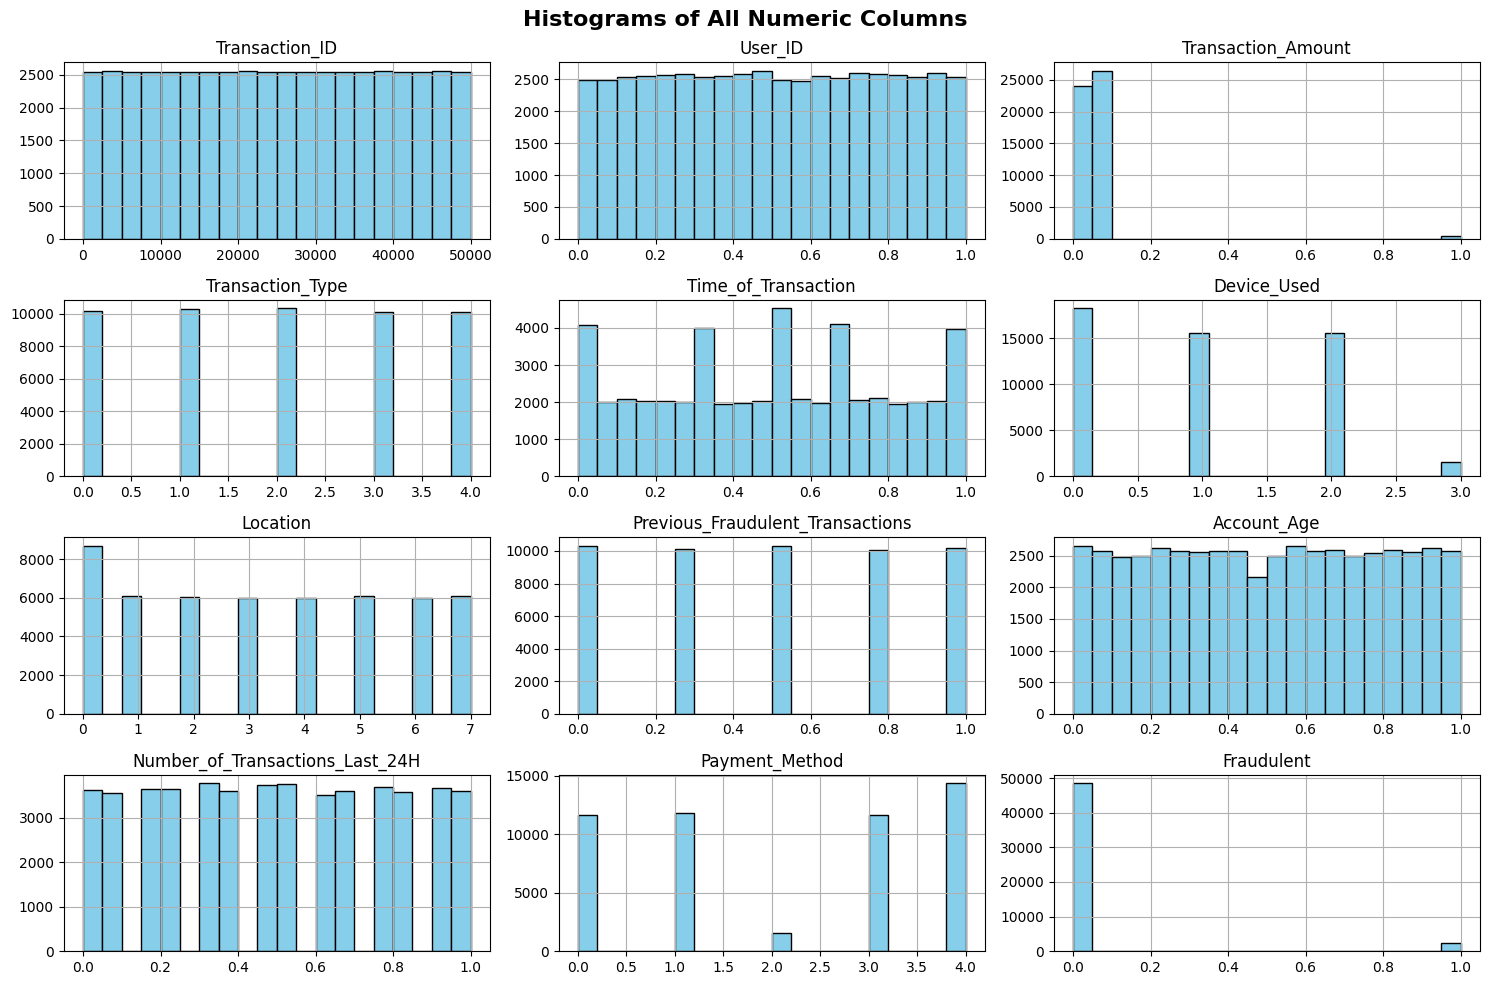

In [42]:
df.hist(figsize=(15,10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Histograms of All Numeric Columns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

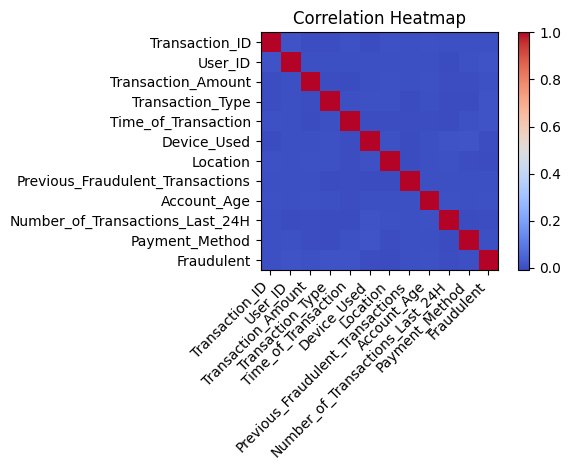

In [44]:
corr = df.corr(numeric_only=True)
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.title('Correlation Heatmap')
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr)), corr.columns)
plt.tight_layout()
plt.show()

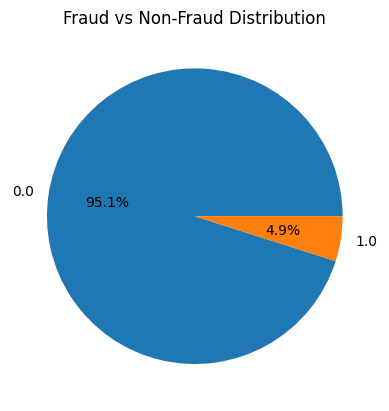

In [48]:
fraud_counts = df['Fraudulent'].value_counts()
plt.figure()
plt.pie(fraud_counts.values, labels=fraud_counts.index.astype(str), autopct='%1.1f%%')
plt.title('Fraud vs Non-Fraud Distribution')
plt.show()

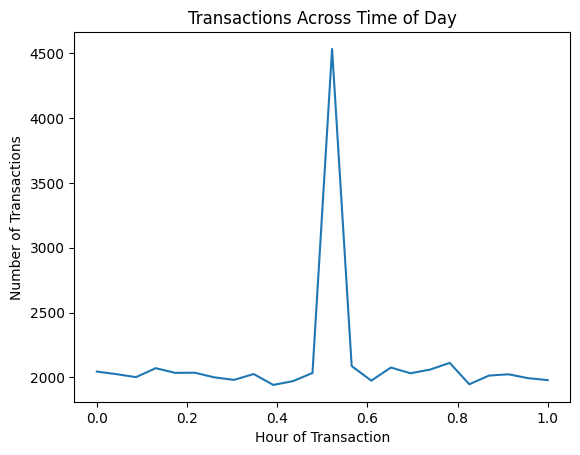

In [50]:
hour_counts = df['Time_of_Transaction'].value_counts().sort_index()
plt.figure()
plt.plot(hour_counts.index, hour_counts.values)
plt.xlabel('Hour of Transaction')
plt.ylabel('Number of Transactions')
plt.title('Transactions Across Time of Day')
plt.show()

<Figure size 640x480 with 0 Axes>

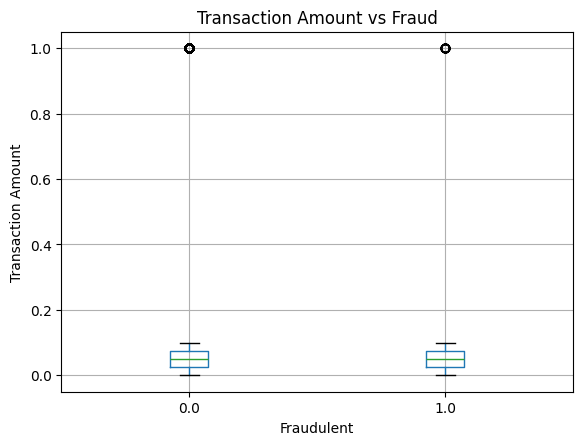

In [57]:
plt.figure()
df.boxplot(column='Transaction_Amount', by='Fraudulent')
plt.xlabel('Fraudulent')
plt.ylabel('Transaction Amount')
plt.title('Transaction Amount vs Fraud')
plt.suptitle('')
plt.show()

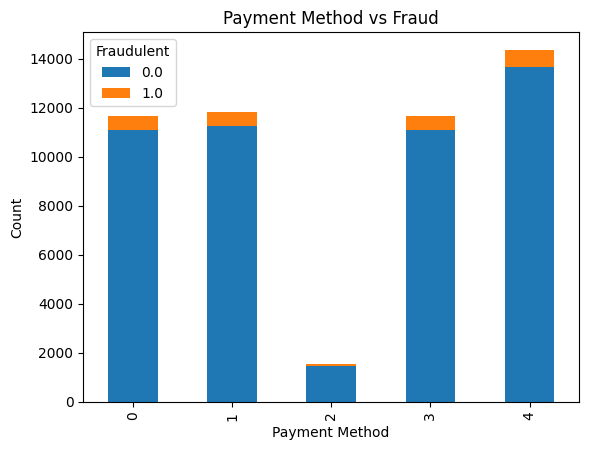

In [58]:
payment_fraud = pd.crosstab(df['Payment_Method'], df['Fraudulent'])
payment_fraud.plot(kind='bar', stacked=True)
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title('Payment Method vs Fraud')
plt.show()

In [59]:
X = df.drop(columns=['Fraudulent', 'Transaction_ID'])
y = df['Fraudulent']

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
#random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.952156862745098


In [69]:
#knn
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.9491176470588235


In [70]:
#svm
from sklearn.svm import SVC
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.9498039215686275
